# 2026-07-20 주문·손익 운영 진단

## tl;dr

- 오늘 주문 0건의 직접 원인은 스케줄러가 `DRY_RUN`으로 실행되어 실제 주문을 의도적으로 전송하지 않는 점이다.
- 동시에 로컬 KRX 달력이 2026-07-17 제헌절을 거래일로 잘못 판정해, 정상적인 7월 16일 종가를 stale 데이터로 폐기했다. 이 때문에 6개 보유종목이 모두 `DATA_UNAVAILABLE_HOLD`로 고정되고 FA 후보도 0개가 됐다.
- 이 결함은 위험청산도 막는다. 현재 삼성전자 포지션은 기록 고점 대비 8% 트레일링 스톱 기준을 넘은 상태인지 아래에서 재계산한다.
- 최근 관측 손익은 부진하지만, 짧고 모드가 섞인 운영 표본만으로 전략의 장기 기대수익을 판단할 수는 없다. 운영 결함을 고친 뒤 실제 주문 가능한 동일 조건으로 재검증해야 한다.

## Context & Methods

### Key Assumptions

- 분석 시각은 노트북 실행 시점의 한국시간이다.
- `logs/paper/account_history.csv`와 `logs/dry_run/account_history.csv`는 동일 KIS 모의계좌의 관측값이지만 실행 모드가 섞여 있어, 단기 운영 관측으로만 사용한다.
- 2026-07-17은 2026년부터 다시 공휴일이 된 제헌절이며 KRX는 공휴일에 휴장한다. 로컬 `exchange_calendars` 판정과 공식 휴일 규칙의 불일치를 운영 결함으로 본다.
- KIS 잔고 조회는 읽기 전용이며 계좌번호와 인증정보는 출력하지 않는다.

In [1]:
from pathlib import Path
import json
import sys
from datetime import date

import matplotlib.pyplot as plt
import pandas as pd

project_root = Path.cwd()
if not (project_root / 'logs').exists():
    project_root = project_root.parents[1]
sys.path.insert(0, str(project_root))

dashboard = json.loads((project_root / 'logs/dry_run/dashboard_state.json').read_text(encoding='utf-8'))
decisions = json.loads((project_root / 'logs/dry_run/decision_state.json').read_text(encoding='utf-8'))
risk_state = json.loads((project_root / 'logs/dry_run/risk_state.json').read_text(encoding='utf-8'))
fa_candidates = json.loads((project_root / 'logs/fa_candidates.json').read_text(encoding='utf-8'))
replay = json.loads((project_root / 'reports/fa_weighting_replay_pass_only/metrics.json').read_text(encoding='utf-8'))

history = pd.concat([
    pd.read_csv(project_root / 'logs/paper/account_history.csv'),
    pd.read_csv(project_root / 'logs/dry_run/account_history.csv'),
], ignore_index=True)
history['timestamp'] = pd.to_datetime(history['timestamp'])
history = history.sort_values('timestamp').reset_index(drop=True)
today = history[(history['mode'] == 'DRY_RUN') & (history['timestamp'].dt.date == date(2026, 7, 20))].copy()

print({
    'dashboard_updated_at': dashboard['updated_at'],
    'execution_mode': decisions['mode'],
    'dashboard_status': dashboard['operational_status'],
    'daily_orders': dashboard['daily_orders'],
    'stale_hold_count': sum(row['signal_reason'] == 'DATA_UNAVAILABLE_HOLD' for row in decisions['decisions']),
    'position_count': len(decisions['decisions']),
    'fa_candidate_count': len(fa_candidates['tickers']),
})

{'dashboard_updated_at': '2026-07-20 11:57:16', 'execution_mode': 'DRY_RUN', 'dashboard_status': 'NORMAL', 'daily_orders': {'buy_filled': 0, 'sell_filled': 0, 'open': 0, 'rejected': 0}, 'stale_hold_count': 6, 'position_count': 6, 'fa_candidate_count': 0}


## Data

### 1. 현재 모의계좌 스냅샷

잔고 API에서 비식별 포지션 수치만 읽고, 로컬 위험상태의 기록 고점과 결합한다.

In [2]:
from core.broker.kis_api import KisBroker

balance = KisBroker(mock=True).get_balance()
position_rows = []
for ticker, position in sorted(balance['positions'].items()):
    qty = float(position['qty'])
    average_price = float(position['avg_price'])
    current_price = float(position['current_price'])
    peak_price = float(risk_state.get(ticker, {}).get('peak_price') or 0)
    position_rows.append({
        'ticker': ticker,
        'qty': qty,
        'average_price': average_price,
        'current_price': current_price,
        'market_value': qty * current_price,
        'unrealized_pnl': qty * (current_price - average_price),
        'return_pct': (current_price / average_price - 1) * 100,
        'peak_price': peak_price,
        'peak_drawdown_pct': (current_price / peak_price - 1) * 100 if peak_price else None,
        'trailing_stop_triggered': bool(peak_price > average_price > 0 and current_price <= peak_price * 0.92),
    })
positions = pd.DataFrame(position_rows)
account_total = float(balance['cash']) + positions['market_value'].sum()
positions[['ticker', 'unrealized_pnl', 'return_pct', 'peak_drawdown_pct', 'trailing_stop_triggered']]

,ticker,unrealized_pnl,return_pct,peak_drawdown_pct,trailing_stop_triggered
0,005930.KS,-4710999.930,-8.357134,-11.985689,True
1,021240.KS,-659899.968,-1.648411,-5.182927,False
2,034730.KS,-1125999.945,-3.245050,-3.284072,False
3,161390.KS,-26516.822,-0.314012,-7.568654,False
4,383220.KS,-2736840.945,-3.791408,-6.296296,False
5,483650.KS,4636208.150,6.614764,-3.828829,False


## Results

### 2. 로컬 거래일 달력과 실제 휴장일의 불일치

In [3]:
from core.utils.trading_calendar import is_krx_trading_day, previous_krx_trading_day

calendar_check = {
    'local_calendar_says_2026_07_17_is_session': is_krx_trading_day('2026-07-17'),
    'local_previous_session_before_2026_07_20': previous_krx_trading_day(date(2026, 7, 20)).isoformat(),
    'actual_last_completed_session': '2026-07-16',
    'official_holiday': '2026-07-17 Constitution Day',
}
calendar_check

{'local_calendar_says_2026_07_17_is_session': True,
 'local_previous_session_before_2026_07_20': '2026-07-17',
 'actual_last_completed_session': '2026-07-16',
 'official_holiday': '2026-07-17 Constitution Day'}

### 3. 오늘 손익과 위험청산 노출

In [4]:
today_open = float(today.iloc[0]['total_asset'])
today_latest = float(today.iloc[-1]['total_asset'])
observed_first = float(history.iloc[0]['total_asset'])
observed_latest = float(history.iloc[-1]['total_asset'])
summary = pd.Series({
    'today_open_asset': today_open,
    'today_latest_asset': today_latest,
    'today_change': today_latest - today_open,
    'today_return_pct': (today_latest / today_open - 1) * 100,
    'observed_start': history.iloc[0]['timestamp'],
    'observed_end': history.iloc[-1]['timestamp'],
    'observed_change': observed_latest - observed_first,
    'observed_return_pct': (observed_latest / observed_first - 1) * 100,
    'current_unrealized_pnl': positions['unrealized_pnl'].sum(),
    'trailing_stop_trigger_count': int(positions['trailing_stop_triggered'].sum()),
    'dashboard_total_slippage': float(dashboard['total_slippage']),
})
summary

today_open_asset                       467920790.0
today_latest_asset                     465390390.0
today_change                            -2530400.0
today_return_pct                         -0.540775
observed_start                 2026-07-13 14:14:46
observed_end                   2026-07-20 11:57:16
observed_change                         -5802057.0
observed_return_pct                      -1.231356
current_unrealized_pnl                 -4624049.46
trailing_stop_trigger_count                      1
dashboard_total_slippage                4279301.75
dtype: object

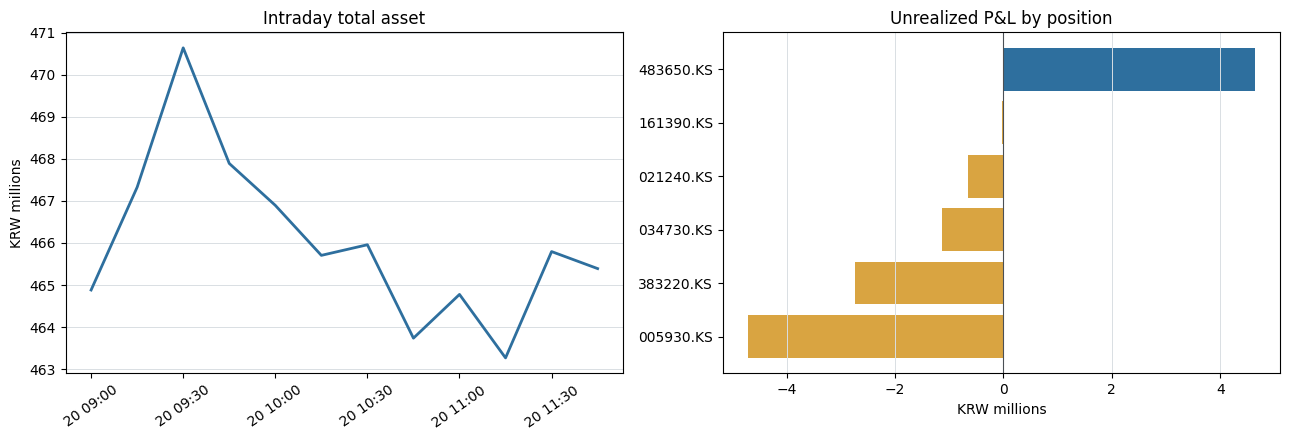

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
sampled_today = today.set_index('timestamp').resample('15min').last().dropna().reset_index()
axes[0].plot(sampled_today['timestamp'], sampled_today['total_asset'] / 1_000_000, color='#2E6F9E', linewidth=2)
axes[0].set_title('Intraday total asset')
axes[0].set_ylabel('KRW millions')
axes[0].grid(axis='y', color='#D9DEE3', linewidth=0.7)
axes[0].tick_params(axis='x', rotation=35)

plot_positions = positions.sort_values('unrealized_pnl')
colors = ['#D9A441' if value < 0 else '#2E6F9E' for value in plot_positions['unrealized_pnl']]
axes[1].barh(plot_positions['ticker'], plot_positions['unrealized_pnl'] / 1_000_000, color=colors)
axes[1].axvline(0, color='#4A4F55', linewidth=0.8)
axes[1].set_title('Unrealized P&L by position')
axes[1].set_xlabel('KRW millions')
axes[1].grid(axis='x', color='#D9DEE3', linewidth=0.7)
plt.tight_layout()
plt.show()

### 4. 장기 리플레이는 긍정적이지만 운영 성과와 동일하지 않다

In [6]:
replay_table = pd.DataFrame(replay['summary']).T[[
    'trading_days', 'total_return', 'sharpe_zero_rf', 'max_drawdown', 'total_cost_ratio'
]]
replay_table

,trading_days,total_return,sharpe_zero_rf,max_drawdown,total_cost_ratio
equal,107.0,0.141661,0.907016,-0.214984,0.022097
fa_direct,107.0,0.154936,0.968823,-0.203028,0.021520
fa_excess,107.0,0.211119,1.215674,-0.169905,0.020131


## Takeaways

1. **주문 0건은 현재 설정상 정상이다.** 스케줄러가 `DRY_RUN`이므로 실제 주문 누적은 항상 0이다. 대시보드가 이를 단순히 ‘오늘 누적 주문’으로 보여주는 것은 지표 라벨 문제다.
2. **후보 주문까지 0건인 것은 비정상이다.** 제헌절 휴장 반영 누락으로 7월 16일 종가가 폐기되어 전 종목이 안전보유 상태로 고정됐다.
3. **위험청산 누락 가능성이 확인된다.** 트레일링 스톱 조건을 충족한 포지션이 있으면 stale 데이터와 별개로 실시간 잔고 가격을 이용해 청산 평가가 가능해야 한다.
4. **전략 수익성 평가는 아직 분리해야 한다.** 최근 운영 표본은 짧고 PAPER/DRY_RUN 모드가 섞였으며, 장기 리플레이는 실제 체결과 동일하지 않다. 달력·상태표시·위험청산 경로 수정 후 동일 조건의 모의주문 성과를 다시 측정해야 한다.